In [15]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

fatal: destination path 'deep-learning-pa1' already exists and is not an empty directory.


In [16]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset

import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# **Parte 1 - Baseline de Segmentação Semântica**

In [18]:
# Treinem uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportem IoU e Dice .
# 2. Extraiam instâncias pelo método ingênuo: limiar + componentes conexos.

class ResUNetEncoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int=2):
        super().__init__()

        self.seq = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)

    def forward(self, x):
        return self.seq(x) + self.shortcut(x)


class ResUNetDecoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, skip_channels: int):
        super().__init__()

        self.seq = nn.Sequential(
            nn.BatchNorm2d(in_channels + skip_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        # up sampling
        self.ups = nn.Sequential(
            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        )

        self.shortcut = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=1)

    # 'skip' aqui é o tensor de skip connection vindo
    # das saídas intermediárias do encoder
    def forward(self, x, skip):
        x = self.ups(x)
        x = torch.cat([x, skip], dim=1) # concat na dimensão 'C'
        return self.seq(x) + self.shortcut(x)


class ResUNet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.enc0 = ResUNetEncoderBlock(in_channels, 64, stride=1)
        self.enc1 = ResUNetEncoderBlock(64, 128)
        self.enc2 = ResUNetEncoderBlock(128, 256)

        self.bridge = ResUNetEncoderBlock(256, 512)

        self.dec0 = ResUNetDecoderBlock(512, 256, 256)
        self.dec1 = ResUNetDecoderBlock(256, 128, 128)
        self.dec2 = ResUNetDecoderBlock(128, 64, 64)

        self.ending = nn.Sequential(
            nn.LazyConv2d(out_channels, kernel_size=1),
            # nn.Sigmoid() -- vamos usar a saída em logits
        )

    def forward(self, x):
        # encoder
        out0 = self.enc0(x)
        out1 = self.enc1(out0)
        out2 = self.enc2(out1)
        # ponte
        y = self.bridge(out2)
        # decoder
        y = self.dec0(y, out2)
        y = self.dec1(y, out1)
        y = self.dec2(y, out0)

        return self.ending(y)

In [19]:
# Instanciando o modelo
model = ResUNet(3, 1).to(device)

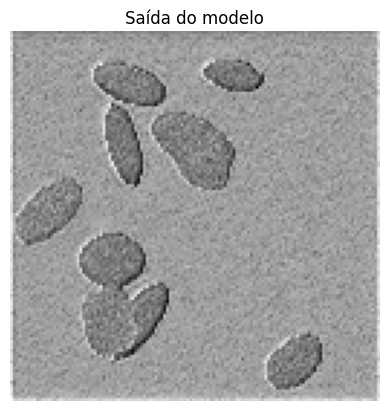

In [20]:
# Teste

model.eval()

dataset = SyntheticEllipseDataset(num_samples=1)
for img, mask in DataLoader(dataset):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))

    # mesmo número de datapoints
    assert y.shape[0] == img.shape[0]
    # shape[1] é o número de canais, que pode variar
    # mesma resolução
    assert y.shape[2] == img.shape[2]
    assert y.shape[3] == img.shape[3]

    fig, ax = plt.subplots()
    ax.imshow(y[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Saída do modelo")
    ax.axis("off")
    plt.show()

    break

In [21]:
# Treinando o modelo no dataset sintético (teste unitário)

dataset = SyntheticEllipseDataset(num_samples=512)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

model.train()
for batch, (X, y) in enumerate(loader):
    X, y = X.to(device), y.to(device)

    y_hat = model(X).squeeze(1)
    loss = loss_fn(y_hat, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 5 == 0:
        print(f'{batch} - loss={loss}')

0 - loss=0.7247214317321777
5 - loss=0.40076035261154175
10 - loss=0.2712831199169159
15 - loss=0.19261673092842102
20 - loss=0.14103782176971436
25 - loss=0.11484355479478836
30 - loss=0.1040208488702774


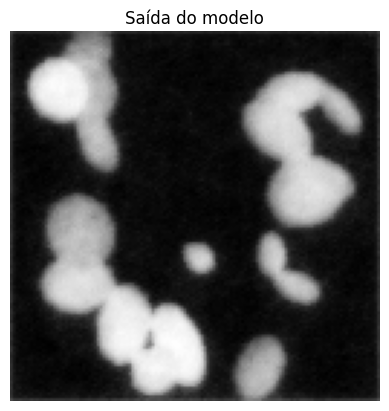

In [23]:
# Teste de sanidade

model.eval()

dataset = SyntheticEllipseDataset(num_samples=1)
for img, mask in DataLoader(dataset):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))

    fig, ax = plt.subplots()
    ax.imshow(y[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Saída do modelo")
    ax.axis("off")
    plt.show()

    break

In [24]:
# Carregando os dados: BBBC038
!wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
!cd data && unzip -q stage1_train.zip -d stage1_train

--2026-09-05 18:27:20--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  38.2MB/s    in 2.1s    

2026-09-05 18:27:23 (38.2 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]



In [25]:
import os
from pathlib import Path
import numpy as np
import torch
from skimage.io import imread
from skimage.transform import resize

IMG_SIZE = 128

class BBBC038Dataset(Dataset):
    def __init__(self):
        self.train_dir = Path("data/stage1_train")
        self.ids = os.listdir(self.train_dir)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id = self.ids[idx]
        self.mask_dir = self.train_dir / id / "masks"
        img_path = self.train_dir / id / "images" / f"{id}.png"
        image = imread(img_path)[..., :3] / 255
        masks = [imread(self.mask_dir / f) for f in os.listdir(self.mask_dir)]
        mask = np.max(masks, axis=0) / 255

        image = resize(image, (IMG_SIZE, IMG_SIZE), preserve_range=True)
        mask = resize(mask, (IMG_SIZE, IMG_SIZE), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        image = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        mask = torch.from_numpy(mask[..., None]).permute(2, 0, 1)[0].contiguous().float()

        return image, mask

(128, 128, 3) (128, 128)
float32 float32
0.3279115 0.012664216 1.0 0.0


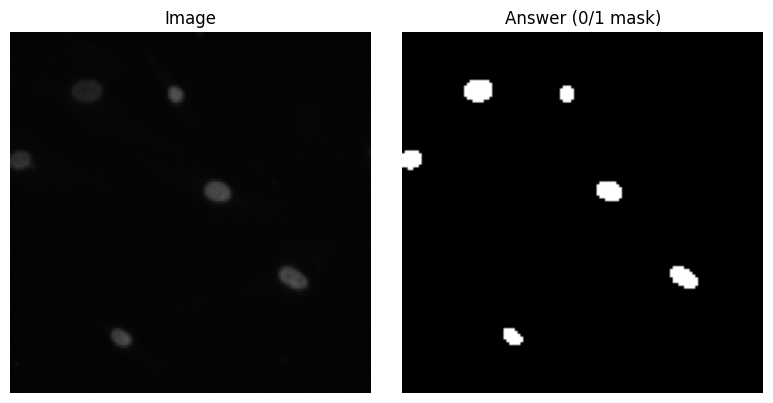

In [26]:
# Testando import do dataset

dataset = BBBC038Dataset()
for img, mask in DataLoader(dataset, shuffle=True):
    img, mask = img[0], mask[0]

    img = img.permute(1, 2, 0).numpy()
    mask = mask.numpy()

    print(img.shape, mask.shape)
    print(img.dtype, mask.dtype)
    print(img.max(), img.min(), mask.max(), mask.min())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    break

In [27]:
# Treinando o modelo no dataset real

model = ResUNet(3, 1).to(device)

dataset = BBBC038Dataset()
loader = DataLoader(dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.5889049768447876
0/5 - loss=0.5151437520980835


KeyboardInterrupt: 

In [ ]:
# Teste de sanidade

model.eval()

dataset = BBBC038Dataset()
for img, mask in DataLoader(dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()

    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")

    plt.show()

    break